# CE49X Lab 3: Where Should You Open a Gas Station in Istanbul?
## A Traffic-Based Site Selection Analysis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

## Background

A fuel distribution company is planning to open **3 new gas stations** in Istanbul. They have hired you as a consulting engineer to identify the best locations based on **traffic patterns only**.

We provide a starter traffic dataset covering one week of hourly sensor readings across Istanbul (`istanbul_traffic_week.csv` + `sensor_coords.csv`). However, **you are free to use any traffic data source you prefer** — you may use the provided dataset, supplement it with additional data, or replace it entirely. Some options:

- **Provided dataset:** `istanbul_traffic_week.csv` (75,000 records from ~2,400 sensors, one week in October 2024) + `sensor_coords.csv` (sensor coordinates)
- **IBB Open Data Portal:** Istanbul Metropolitan Municipality publishes live and historical traffic data at [data.ibb.gov.tr](https://data.ibb.gov.tr). You can query their APIs for broader coverage or more recent data.
- **Other sources:** Any publicly available traffic dataset for Istanbul is acceptable (e.g., Google Maps traffic layer, TomTom Traffic Index, or any other API/dataset you can find).

**Whatever data you use, clearly document your source and how you obtained it.**

Your job is to:
1. **Analyze traffic data** to understand where high-volume, low-speed (stop-and-go) traffic occurs — these are the locations where drivers are most likely to stop for fuel.
2. **Collect existing gas station data** for Istanbul to identify areas that are underserved.
3. **Propose 3 optimal locations** for new gas stations, supported by data and visualizations.

## Provided Data (Optional Starting Point)

The following files are included in the course repository. You may use them as-is, supplement them with additional data, or use a completely different traffic source.

### `istanbul_traffic_week.csv`

| Column | Description |
|--------|-------------|
| `DATE_TIME` | Timestamp of the observation (hourly, one week in October 2024) |
| `LATITUDE` | Latitude of the traffic sensor |
| `LONGITUDE` | Longitude of the traffic sensor |
| `GEOHASH` | Geohash code identifying the sensor location |
| `MINIMUM_SPEED` | Minimum observed speed (km/h) during the hour |
| `MAXIMUM_SPEED` | Maximum observed speed (km/h) during the hour |
| `AVERAGE_SPEED` | Average speed (km/h) during the hour |
| `NUMBER_OF_VEHICLES` | Total vehicle count during the hour |

### `sensor_coords.csv`

| Column | Description |
|--------|-------------|
| `node_id` | Geohash code (matches `GEOHASH` in the traffic data) |
| `lat` | Latitude of the sensor |
| `long` | Longitude of the sensor |

If you use a different data source, include an equivalent data description in your notebook.

## Deliverables

Your notebook must include the following:

### 1. Traffic Data — Source & Exploration
- **Document your traffic data source.** If you use the provided dataset, state that. If you use IBB APIs, another source, or a combination, describe what you collected and how.
- Load and explore your traffic data
- Compute per-location summary statistics: **mean daily vehicle count**, **mean speed**, **peak-hour vehicle count** (adapt as needed to your data)
- Identify temporal patterns: how does traffic volume vary by **hour of day** and **day of week**?
- Identify the **top 20 highest-traffic locations** by total vehicle count

### 2. Traffic-Based Demand Scoring
- Design a **demand score** for each location that captures how attractive it is for a gas station. Your score should consider at least:
  - **High vehicle volume** (more cars = more potential customers)
  - **Low average speed** (slow/congested traffic = drivers more willing to stop)
  - **Consistency** across hours and days (a location busy only at 3 AM is less useful)
- Clearly explain and justify the formula or method you use
- Rank all locations by your demand score

### 3. Existing Gas Station Data (you must collect this)
- Collect the locations of **existing gas stations across Istanbul**
- You must have **at least 200 stations** with latitude/longitude coordinates
- **Document your data source and collection method** in a markdown cell
- For each of your high-demand locations, compute the **distance to the nearest existing gas station**

### 4. Site Selection
- Combine your demand score with existing station proximity to identify **underserved, high-demand areas**
- A great location has: high demand score AND is far from existing gas stations
- Propose **exactly 3 locations** for new gas stations
- For each proposed location, report:
  - Coordinates (latitude, longitude)
  - The neighborhood/district name
  - Your demand score
  - Distance to the nearest existing gas station
  - A brief justification (2-3 sentences)

### 5. Visualizations
- Create **at least three plots/maps**. Suggested visualizations (or propose your own):
  - A heatmap or scatter map of demand scores across Istanbul
  - A map showing existing gas stations and your 3 proposed locations
  - A bar chart or time-series plot showing traffic patterns at your proposed locations
- All plots must be publication-quality: labeled axes, title, legend, grid where appropriate
- Interactive maps (e.g., folium) are encouraged but not required

### 6. Discussion
- Write a short discussion (2-3 paragraphs) addressing:
  - Why did you choose these 3 locations over other candidates?
  - What **limitations** does a traffic-only analysis have? What other factors would a real site selection study consider (e.g., land cost, zoning, competition, road type)?
  - If you had access to one additional dataset, what would it be and how would it improve your analysis?

## Hints

- **Haversine formula** for distance between two GPS coordinates:

$$d = 2R \arcsin\left(\sqrt{\sin^2\left(\frac{\Delta\phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta\lambda}{2}\right)}\right)$$

  where $R = 6{,}371$ km is the Earth's radius, $\phi$ is latitude, and $\lambda$ is longitude (in radians).

- **Normalizing scores:** When combining metrics with different scales (e.g., vehicle count vs. speed), normalize each to a 0-1 range first:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- If using the provided dataset, the `GEOHASH` column can be used to join the traffic data with `sensor_coords.csv` via the `node_id` column.

- Think about whether **weekday** vs. **weekend** traffic patterns matter for a gas station business.

## Grading

| Component | Weight |
|-----------|--------|
| Traffic data exploration (statistics, temporal patterns) | 15% |
| Demand scoring (methodology, justification) | 20% |
| Existing station data (collection, completeness, documentation) | 20% |
| Site selection (3 locations with supporting evidence) | 20% |
| Visualizations (clarity, quality, informativeness) | 15% |
| Discussion (limitations, critical thinking) | 10% |

## Submission

1. Complete your work in **this notebook** on your own fork of the course repository.
2. Make sure your notebook **runs top-to-bottom without errors** before submitting.
3. Commit and push your completed notebook to your fork.
4. We will grade directly from your fork — there is no separate upload. Make sure your latest work is pushed before the deadline.

---
## Your Work Starts Here

Traffic rows (cleaned): 74,172
Unique locations: 2,405
Date range: 2024-10-01 00:00:00 -> 2024-10-07 23:00:00

Per-location stats sample:


,location_id,LATITUDE,LONGITUDE,mean_daily_vehicles,mean_speed_kmh,rush_hour_peak_vehicles
0,sx7cmm,41.031189,28.009644,138.857143,81.500000,63.0
1,sx7cmq,41.036682,28.009644,79.142857,81.192308,23.0
2,sx7cmw,41.036682,28.020630,142.714286,86.259259,48.0
3,sx7cmx,41.042175,28.020630,36.714286,86.600000,21.0
4,sx7cmz,41.042175,28.031616,156.285714,80.354839,44.0



Hour/day patterns...


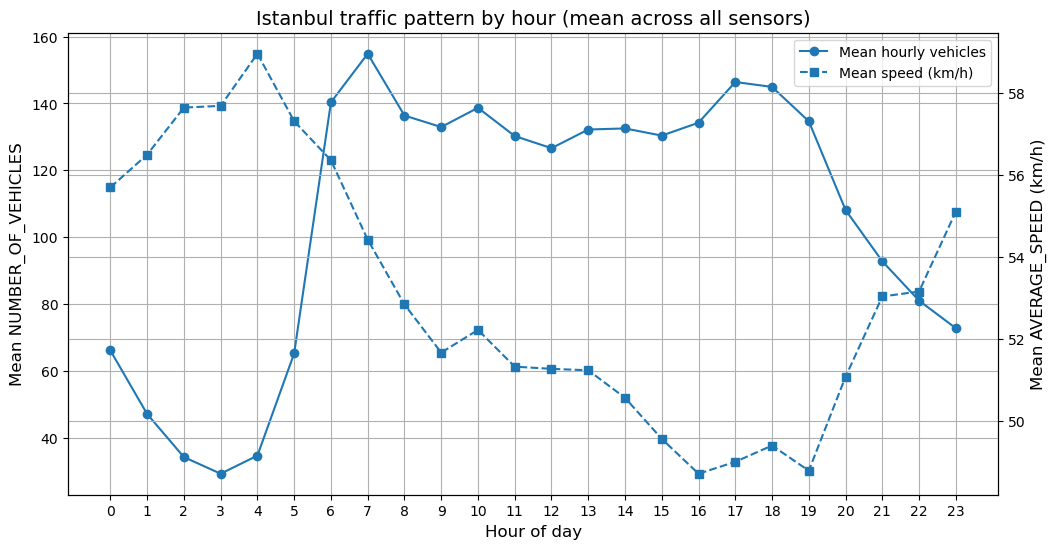

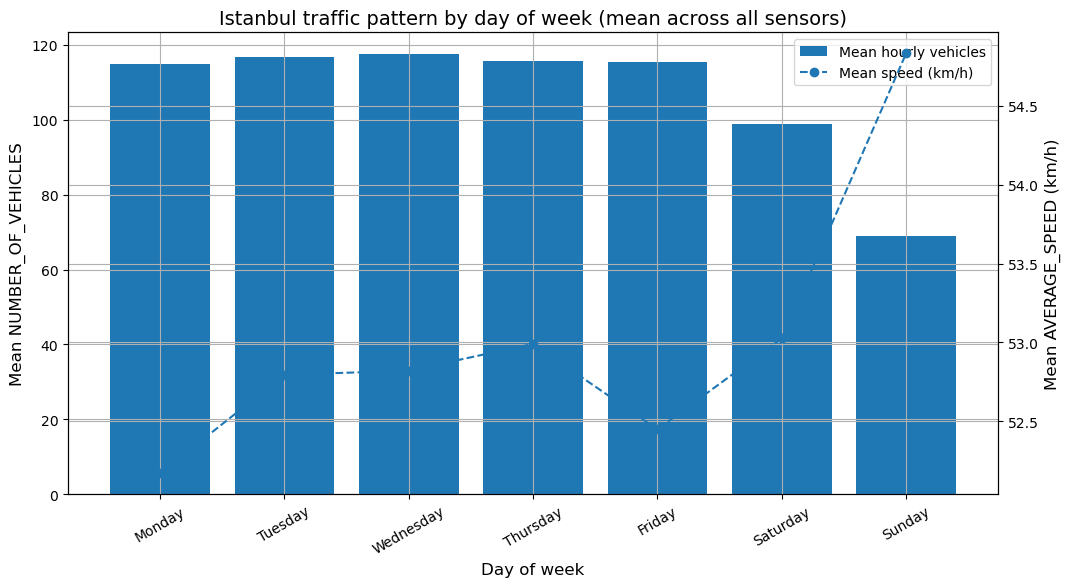


Top 20 locations by TOTAL vehicle count (week):


,location_id,total_vehicles,mean_speed,lat,lon
1643,sxk9vb,79395,54.613095,41.091614,29.086304
1617,sxk9ub,69174,61.369048,41.091614,29.042358
1634,sxk9v0,62832,69.714286,41.091614,29.053345
1615,sxk9u8,62566,58.339286,41.091614,29.031372
1642,sxk9v8,61223,66.976190,41.091614,29.075317
1636,sxk9v2,59363,69.827381,41.091614,29.064331
1390,sxk9ku,57254,37.232143,41.025696,29.042358
1550,sxk9s5,53333,38.732143,41.064148,29.009399
1560,sxk9sh,50627,36.630952,41.069641,29.009399
1401,sxk9m5,45778,45.232143,41.020203,29.053345



Demand score ranking (top 20):


,demand_rank,location_id,LATITUDE,LONGITUDE,mean_daily_vehicles,mean_speed_kmh,rush_hour_peak_vehicles,inv_cv_hourly_vehicles,demand_score
0,1,sxk9kp,41.042175,29.009399,2655.571429,19.166667,213.0,2.395753,0.727036
1,2,sxk9kg,41.020203,29.042358,4825.571429,28.958333,504.0,1.701048,0.693008
2,3,sxk9s1,41.053162,29.009399,3342.428571,33.571429,315.0,2.239553,0.674352
3,4,sxk9sh,41.069641,29.009399,7232.428571,36.630952,719.0,2.125655,0.672340
4,5,sxk9s5,41.064148,29.009399,7619.000000,38.732143,778.0,2.200796,0.667408
5,6,sxk9s7,41.064148,29.020386,3830.571429,41.577381,358.0,2.285225,0.661214
6,7,sxk9s3,41.053162,29.020386,4921.142857,45.035714,451.0,2.478927,0.661001
7,8,sxk9s9,41.053162,29.031372,4694.285714,50.672619,389.0,2.721411,0.659732
8,9,sxk9s8,41.047668,29.031372,5262.571429,51.023810,435.0,2.671778,0.655923
9,10,sxk9ku,41.025696,29.042358,8179.142857,37.232143,876.0,1.889636,0.655529



Generating demand map...



Overpass query: amenity=fuel within Istanbul bbox; uses retries and bbox-tiling if needed.
Collected gas stations: 797

Feasibility exclusion results:
Candidates before exclusions: 2,405
Removed by exclusions: 159


,removed_count
removed_by,
FSM Bridge & approaches,56
15 July Martyrs Bridge & approaches,44
Eurasia Tunnel corridor (approx),38
Yavuz Sultan Selim Bridge & approaches,21


Candidates after exclusions: 2,246

Generating stations + proposed sites map...



Plotting traffic patterns for the 3 proposed sites...


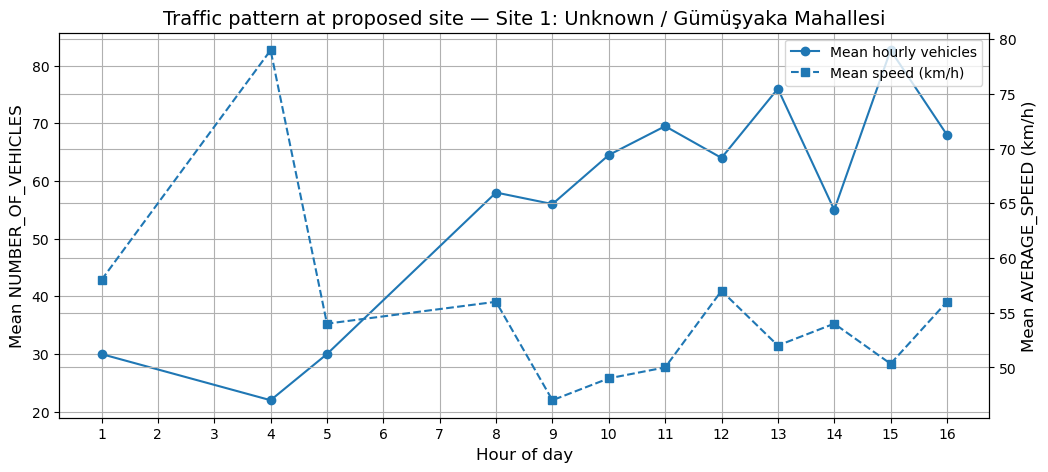

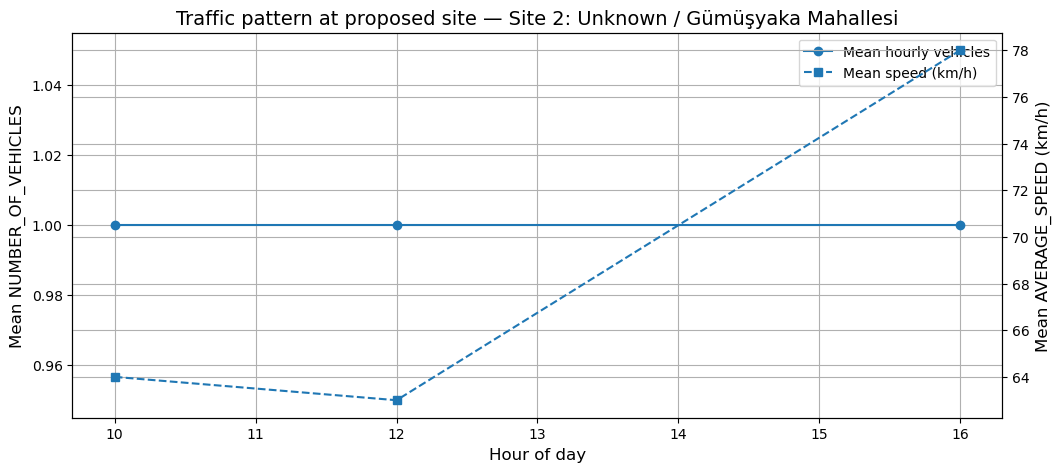

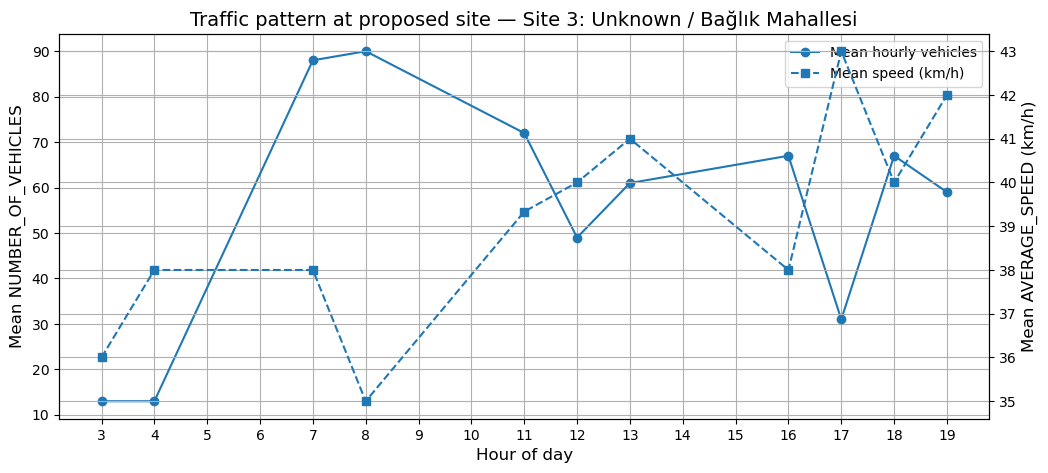


FINAL PROPOSED SITES (exactly 3 if feasible):


,final_rank,LATITUDE,LONGITUDE,district,neighborhood,demand_score,nearest_station_km,justification
0,1,41.047668,28.042603,Unknown,Gümüşyaka Mahallesi,0.215913,32.371156,This site ranks highly on the traffic-based de...
1,2,41.075134,28.064575,Unknown,Gümüşyaka Mahallesi,0.229389,30.368837,This site ranks highly on the traffic-based de...
2,3,41.305847,28.009644,Unknown,Bağlık Mahallesi,0.192861,38.060927,This site ranks highly on the traffic-based de...



Pairwise distances between selected sites (km):
Site 1 ↔ Site 2: 3.57 km
Site 1 ↔ Site 3: 28.84 km
Site 2 ↔ Site 3: 26.06 km


In [4]:


import os
import json
import time
import math
import warnings
from typing import Tuple, Dict, Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import requests
import folium
from folium.plugins import HeatMap

# Optional: scikit-learn for fast nearest-neighbor via BallTree (haversine)
try:
    from sklearn.neighbors import BallTree
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False
    BallTree = None

warnings.filterwarnings("ignore", category=UserWarning)

# %%
# =========================
# Global configuration
# =========================
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

R_EARTH_KM = 6371.0

TRAFFIC_FILE_CANDIDATES = [
    "istanbul_traffic_week.csv",
    "/mnt/data/istanbul_traffic_week.csv",  # common mounted path in some environments
]

SENSOR_FILE_CANDIDATES = [
    "sensor_coords.csv",
    "/mnt/data/sensor_coords.csv",
]

# Istanbul broad bounding box (approx)
ISTANBUL_BBOX = {
    "south": 40.80,
    "west": 28.40,
    "north": 41.60,
    "east": 29.70
}

# Exclusion bounding boxes (approx) for feasibility constraints
EXCLUSION_ZONES = [
    {
        "name": "15 July Martyrs Bridge & approaches",
        "south": 41.030,
        "west": 29.010,
        "north": 41.080,
        "east": 29.070
    },
    {
        "name": "FSM Bridge & approaches",
        "south": 41.070,
        "west": 29.030,
        "north": 41.125,
        "east": 29.105
    },
    {
        "name": "Yavuz Sultan Selim Bridge & approaches",
        "south": 41.195,
        "west": 29.090,
        "north": 41.285,
        "east": 29.240
    },
    {
        "name": "Eurasia Tunnel corridor (approx)",
        "south": 40.970,
        "west": 28.980,
        "north": 41.020,
        "east": 29.060
    },
]

# Nominatim (reverse geocoding)
NOMINATIM_URL = "https://nominatim.openstreetmap.org/reverse"
NOMINATIM_USER_AGENT = "CE49X-Lab3-GasStationSiteSelection/1.0 (educational use)"
GEOCODE_CACHE_FILE = "nominatim_cache.json"

# Overpass API endpoints (we try multiple)
OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass.nchc.org.tw/api/interpreter",
]

# %%
# =========================
# Utility helpers
# =========================
def find_existing_file(candidates: List[str]) -> Optional[str]:
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

def assert_columns(df: pd.DataFrame, required: List[str], df_name: str = "DataFrame") -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}. Found columns: {list(df.columns)}")

def safe_to_datetime(s: pd.Series) -> pd.Series:
    # Robust parsing for mixed formats; coerce errors to NaT
    return pd.to_datetime(s, errors="coerce", utc=False)

def clip_lat_lon(df: pd.DataFrame, lat_col: str, lon_col: str) -> pd.DataFrame:
    df = df.copy()
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    # Istanbul-ish sanity bounds (wide to avoid false drops)
    valid = (
        df[lat_col].between(40.5, 41.8) &
        df[lon_col].between(28.0, 30.0)
    )
    before = len(df)
    df = df[valid].copy()
    after = len(df)
    if after < before:
        warnings.warn(f"Dropped {before-after:,} rows with invalid coordinates.")
    return df

def winsorize_series(x: pd.Series, lower_q: float = 0.01, upper_q: float = 0.99) -> pd.Series:
    x = x.astype(float)
    lo = x.quantile(lower_q)
    hi = x.quantile(upper_q)
    return x.clip(lower=lo, upper=hi)

def minmax_norm(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    denom = (x.max() - x.min())
    if denom == 0 or np.isclose(denom, 0):
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - x.min()) / denom

def haversine_km(lat1, lon1, lat2, lon2) -> np.ndarray:
    """
    Vectorized haversine.
    lat1, lon1 can be arrays; lat2, lon2 can be arrays/broadcastable.
    Returns distance in km.
    """
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R_EARTH_KM * c

def point_in_bbox(lat: float, lon: float, bbox: Dict[str, float]) -> bool:
    return (bbox["south"] <= lat <= bbox["north"]) and (bbox["west"] <= lon <= bbox["east"])

def apply_exclusion_zones(candidates: pd.DataFrame, lat_col: str = "LATITUDE", lon_col: str = "LONGITUDE") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      kept_df, removed_df (with a column 'removed_by' describing which zone)
    """
    kept = candidates.copy()
    removed_records = []

    mask_remove_any = np.zeros(len(kept), dtype=bool)
    removed_by = np.array([""] * len(kept), dtype=object)

    for zone in EXCLUSION_ZONES:
        zone_mask = kept.apply(lambda r: point_in_bbox(float(r[lat_col]), float(r[lon_col]), zone), axis=1).values
        newly = zone_mask & (~mask_remove_any)
        removed_by[newly] = zone["name"]
        mask_remove_any = mask_remove_any | zone_mask

    removed_df = kept[mask_remove_any].copy()
    if len(removed_df) > 0:
        removed_df["removed_by"] = removed_by[mask_remove_any]

    kept_df = kept[~mask_remove_any].copy()
    return kept_df, removed_df

# %%
# =========================
# 1) Load + clean traffic data
# =========================
def load_traffic_data() -> pd.DataFrame:
    traffic_path = find_existing_file(TRAFFIC_FILE_CANDIDATES)
    if not traffic_path:
        raise FileNotFoundError("Could not find istanbul_traffic_week.csv in working directory or /mnt/data/")

    df = pd.read_csv(traffic_path)
    # Normalize column names (just in case)
    df.columns = [c.strip() for c in df.columns]

    required = ["DATE_TIME", "LATITUDE", "LONGITUDE", "AVERAGE_SPEED", "NUMBER_OF_VEHICLES"]
    assert_columns(df, required, "traffic")

    # Parse datetime
    df["DATE_TIME"] = safe_to_datetime(df["DATE_TIME"])
    before = len(df)
    df = df.dropna(subset=["DATE_TIME"]).copy()
    after = len(df)
    if after < before:
        warnings.warn(f"Dropped {before-after:,} rows with unparseable DATE_TIME.")

    # Coerce numerics
    for c in ["AVERAGE_SPEED", "MINIMUM_SPEED", "MAXIMUM_SPEED", "NUMBER_OF_VEHICLES"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop rows missing core measures
    df = df.dropna(subset=["AVERAGE_SPEED", "NUMBER_OF_VEHICLES", "LATITUDE", "LONGITUDE"]).copy()

    # Remove duplicates
    df = df.drop_duplicates()

    # Coordinate sanity
    df = clip_lat_lon(df, "LATITUDE", "LONGITUDE")

    # Speed sanity (km/h): clip to [1, 140] to avoid zeros/negatives/extremes
    df["AVERAGE_SPEED"] = df["AVERAGE_SPEED"].clip(lower=1, upper=140)

    # Vehicles sanity: clip negatives to 0; winsorize later for scoring
    df["NUMBER_OF_VEHICLES"] = df["NUMBER_OF_VEHICLES"].clip(lower=0)

    # Create time features
    df["date"] = df["DATE_TIME"].dt.date
    df["hour"] = df["DATE_TIME"].dt.hour
    df["day_name"] = df["DATE_TIME"].dt.day_name()
    df["dow"] = df["DATE_TIME"].dt.dayofweek  # Monday=0

    # Location key: prefer GEOHASH if present
    if "GEOHASH" in df.columns and df["GEOHASH"].notna().mean() > 0.9:
        df["location_id"] = df["GEOHASH"].astype(str)
    else:
        # fallback to rounded lat/lon
        df["location_id"] = (
            df["LATITUDE"].round(6).astype(str) + "_" + df["LONGITUDE"].round(6).astype(str)
        )

    # Basic sanity assertions
    assert df["location_id"].nunique() > 50, "Unexpectedly low number of locations after cleaning."
    assert df["DATE_TIME"].nunique() > 24, "Unexpectedly few timestamps after cleaning."
    return df

# %%
# Optional: load sensor coordinates (not strictly needed if traffic already contains lat/lon),
# but we support it per lab description.
def load_sensor_coords() -> Optional[pd.DataFrame]:
    sensor_path = find_existing_file(SENSOR_FILE_CANDIDATES)
    if not sensor_path:
        return None
    sc = pd.read_csv(sensor_path)
    sc.columns = [c.strip() for c in sc.columns]
    # Expected columns: node_id, lat, long
    if not set(["node_id", "lat", "long"]).issubset(set(sc.columns)):
        warnings.warn("sensor_coords.csv found but does not have expected columns (node_id, lat, long). Skipping.")
        return None
    sc = sc.dropna(subset=["node_id", "lat", "long"]).drop_duplicates()
    sc["lat"] = pd.to_numeric(sc["lat"], errors="coerce")
    sc["long"] = pd.to_numeric(sc["long"], errors="coerce")
    sc = sc.dropna(subset=["lat", "long"])
    sc = clip_lat_lon(sc.rename(columns={"lat": "LATITUDE", "long": "LONGITUDE"}), "LATITUDE", "LONGITUDE").rename(
        columns={"LATITUDE": "lat", "LONGITUDE": "long"}
    )
    return sc

# %%
# =========================
# Traffic exploration outputs (rubric)
# =========================
def compute_location_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Per-location summary:
      - mean_daily_vehicles
      - mean_speed
      - rush_hour_peak_vehicles (peak hourly within rush windows 07-10 & 16-19)
    """
    # Mean speed per location over all hours
    mean_speed = df.groupby("location_id")["AVERAGE_SPEED"].mean().rename("mean_speed_kmh")

    # Mean daily vehicle count: sum vehicles per day then average across days
    daily = df.groupby(["location_id", "date"])["NUMBER_OF_VEHICLES"].sum().rename("daily_vehicles").reset_index()
    mean_daily = daily.groupby("location_id")["daily_vehicles"].mean().rename("mean_daily_vehicles")

    # Rush-hour peak: among rush hours, take max hourly vehicle count (per location)
    rush_mask = df["hour"].isin([7, 8, 9, 16, 17, 18])  # 07–10 and 16–19 (exclusive end)
    rush = df[rush_mask].copy()
    rush_peak = rush.groupby("location_id")["NUMBER_OF_VEHICLES"].max().rename("rush_hour_peak_vehicles")

    # Representative coordinates per location (median to reduce outliers)
    coords = df.groupby("location_id")[["LATITUDE", "LONGITUDE"]].median()

    out = pd.concat([coords, mean_daily, mean_speed, rush_peak], axis=1).reset_index()
    out = out.dropna(subset=["LATITUDE", "LONGITUDE", "mean_daily_vehicles", "mean_speed_kmh"])
    return out

def plot_hour_day_patterns(df: pd.DataFrame) -> None:
    # Hour-of-day pattern (volume + speed)
    hourly = df.groupby("hour").agg(
        mean_vehicles=("NUMBER_OF_VEHICLES", "mean"),
        mean_speed=("AVERAGE_SPEED", "mean")
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(hourly["hour"], hourly["mean_vehicles"], marker="o", label="Mean hourly vehicles")
    ax1.set_xlabel("Hour of day")
    ax1.set_ylabel("Mean NUMBER_OF_VEHICLES")
    ax1.set_title("Istanbul traffic pattern by hour (mean across all sensors)")
    ax1.set_xticks(range(0, 24, 1))

    ax2 = ax1.twinx()
    ax2.plot(hourly["hour"], hourly["mean_speed"], marker="s", linestyle="--", label="Mean speed (km/h)")
    ax2.set_ylabel("Mean AVERAGE_SPEED (km/h)")

    # Combined legend
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.show()

    # Day-of-week pattern
    dow = df.groupby(["dow", "day_name"]).agg(
        mean_vehicles=("NUMBER_OF_VEHICLES", "mean"),
        mean_speed=("AVERAGE_SPEED", "mean")
    ).reset_index().sort_values("dow")

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(dow["day_name"], dow["mean_vehicles"], label="Mean hourly vehicles")
    ax.set_title("Istanbul traffic pattern by day of week (mean across all sensors)")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Mean NUMBER_OF_VEHICLES")
    ax.tick_params(axis="x", rotation=30)

    ax2 = ax.twinx()
    ax2.plot(dow["day_name"], dow["mean_speed"], marker="o", linestyle="--", label="Mean speed (km/h)")
    ax2.set_ylabel("Mean AVERAGE_SPEED (km/h)")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.show()

def top_20_locations_by_total_volume(df: pd.DataFrame) -> pd.DataFrame:
    top = df.groupby("location_id").agg(
        total_vehicles=("NUMBER_OF_VEHICLES", "sum"),
        mean_speed=("AVERAGE_SPEED", "mean"),
        lat=("LATITUDE", "median"),
        lon=("LONGITUDE", "median")
    ).reset_index().sort_values("total_vehicles", ascending=False).head(20)
    return top

# %%
# =========================
# 2) Demand score construction (rubric)
# =========================
def compute_demand_scores(loc_stats: pd.DataFrame) -> pd.DataFrame:
    """
    Builds demand score using:
      - Volume: mean_daily_vehicles
      - Congestion: inverse mean_speed_kmh
      - Consistency: inverse CV of hourly vehicles (computed separately and merged in main)
    """
    df = loc_stats.copy()

    # Winsorize for robustness
    df["mean_daily_vehicles_w"] = winsorize_series(df["mean_daily_vehicles"])
    df["mean_speed_kmh_w"] = winsorize_series(df["mean_speed_kmh"])

    # Congestion proxy: inverse speed (higher = more congested)
    df["congestion_raw"] = 1.0 / (df["mean_speed_kmh_w"] + 1e-6)
    df["congestion_w"] = winsorize_series(df["congestion_raw"])

    # Consistency already present as inv_cv (higher better) if merged
    if "inv_cv_hourly_vehicles" not in df.columns:
        df["inv_cv_hourly_vehicles"] = 0.0
    df["inv_cv_w"] = winsorize_series(df["inv_cv_hourly_vehicles"])

    # Normalize each metric to 0-1
    df["vol_norm"] = minmax_norm(df["mean_daily_vehicles_w"])
    df["cong_norm"] = minmax_norm(df["congestion_w"])
    df["cons_norm"] = minmax_norm(df["inv_cv_w"])

    # Weights (justified in Markdown above)
    w_vol, w_cong, w_cons = 0.50, 0.30, 0.20
    df["demand_score"] = (w_vol * df["vol_norm"] + w_cong * df["cong_norm"] + w_cons * df["cons_norm"])

    # Rank
    df = df.sort_values("demand_score", ascending=False).reset_index(drop=True)
    df["demand_rank"] = np.arange(1, len(df) + 1)
    return df

def compute_hourly_consistency(df: pd.DataFrame) -> pd.DataFrame:
    """
    Consistency metric: inverse CV of hourly vehicle count per location.
    CV = std/mean over hourly observations.
    inv_cv = 1 / (CV + eps)
    """
    g = df.groupby("location_id")["NUMBER_OF_VEHICLES"]
    mean_h = g.mean()
    std_h = g.std(ddof=0)
    cv = (std_h / (mean_h + 1e-6)).replace([np.inf, -np.inf], np.nan).fillna(np.nan)
    inv_cv = 1.0 / (cv + 1e-3)  # eps for stability
    out = inv_cv.rename("inv_cv_hourly_vehicles").reset_index()
    return out

# %%
# =========================
# 3) Existing gas station data from OSM Overpass (rubric)
# =========================
def overpass_query_for_bbox(south: float, west: float, north: float, east: float) -> str:
    """
    Collect gas stations (amenity=fuel) within bbox.
    """
    return f"""
    [out:json][timeout:60];
    (
      node["amenity"="fuel"]({south},{west},{north},{east});
      way["amenity"="fuel"]({south},{west},{north},{east});
      relation["amenity"="fuel"]({south},{west},{north},{east});
    );
    out center;
    """

def request_with_retries(url: str, method: str = "GET", max_retries: int = 6, backoff: float = 1.5,
                         timeout: int = 60, **kwargs) -> requests.Response:
    last_exc = None
    for i in range(max_retries):
        try:
            resp = requests.request(method, url, timeout=timeout, **kwargs)
            if resp.status_code in (429, 502, 503, 504):
                sleep_s = (backoff ** i) + np.random.uniform(0, 0.5)
                time.sleep(sleep_s)
                continue
            resp.raise_for_status()
            return resp
        except Exception as e:
            last_exc = e
            sleep_s = (backoff ** i) + np.random.uniform(0, 0.5)
            time.sleep(sleep_s)
    raise RuntimeError(f"Request failed after retries: {last_exc}")

def tile_bbox(bbox: Dict[str, float], tile_deg: float = 0.15) -> List[Tuple[float, float, float, float]]:
    """
    Split bbox into tiles to avoid Overpass limits.
    tile_deg ~ 0.15 deg ~ 15-17 km in latitude.
    """
    south, west, north, east = bbox["south"], bbox["west"], bbox["north"], bbox["east"]
    tiles = []
    lat = south
    while lat < north:
        lat2 = min(lat + tile_deg, north)
        lon = west
        while lon < east:
            lon2 = min(lon + tile_deg, east)
            tiles.append((lat, lon, lat2, lon2))
            lon = lon2
        lat = lat2
    return tiles

def parse_overpass_elements(data: Dict[str, Any]) -> pd.DataFrame:
    elements = data.get("elements", [])
    rows = []
    for el in elements:
        el_type = el.get("type")
        el_id = el.get("id")
        tags = el.get("tags", {}) or {}
        name = tags.get("name", None)

        if el_type == "node":
            lat = el.get("lat", None)
            lon = el.get("lon", None)
        else:
            center = el.get("center", {}) or {}
            lat = center.get("lat", None)
            lon = center.get("lon", None)

        if lat is None or lon is None:
            continue

        rows.append({
            "osm_type": el_type,
            "osm_id": el_id,
            "name": name,
            "lat": lat,
            "lon": lon
        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df = df.dropna(subset=["lat", "lon"]).drop_duplicates(subset=["osm_type", "osm_id"])
    df = clip_lat_lon(df.rename(columns={"lat": "LATITUDE", "lon": "LONGITUDE"}), "LATITUDE", "LONGITUDE").rename(
        columns={"LATITUDE": "lat", "LONGITUDE": "lon"}
    )
    return df

def collect_gas_stations_osm(bbox: Dict[str, float], min_required: int = 200) -> pd.DataFrame:
    """
    Collect gas stations via Overpass. Strategy:
      1) Try single bbox query.
      2) If < min_required OR request fails, tile bbox and query tiles, concatenate.
      3) Deduplicate.
    """
    stations_all = []

    def try_endpoints(query: str) -> Optional[Dict[str, Any]]:
        for endpoint in OVERPASS_ENDPOINTS:
            try:
                resp = request_with_retries(endpoint, method="POST", data=query.encode("utf-8"),
                                            headers={"Content-Type": "text/plain; charset=utf-8"})
                return resp.json()
            except Exception:
                continue
        return None

    # Attempt 1: single bbox
    q1 = overpass_query_for_bbox(bbox["south"], bbox["west"], bbox["north"], bbox["east"])
    data = try_endpoints(q1)
    if data is not None:
        df1 = parse_overpass_elements(data)
        stations_all.append(df1)

    stations = pd.concat(stations_all, ignore_index=True) if stations_all else pd.DataFrame()
    if len(stations) >= min_required:
        stations = stations.drop_duplicates(subset=["lat", "lon"])
        return stations

    # Attempt 2: tiled bbox
    tiles = tile_bbox(bbox, tile_deg=0.12)
    for (s, w, n, e) in tiles:
        q = overpass_query_for_bbox(s, w, n, e)
        data = try_endpoints(q)
        if data is None:
            continue
        dft = parse_overpass_elements(data)
        if len(dft) > 0:
            stations_all.append(dft)
        # Light pacing to avoid hammering endpoints
        time.sleep(0.2)

    if stations_all:
        stations = pd.concat(stations_all, ignore_index=True)
    else:
        stations = pd.DataFrame(columns=["osm_type", "osm_id", "name", "lat", "lon"])

    stations = stations.drop_duplicates(subset=["osm_type", "osm_id"])
    stations = stations.drop_duplicates(subset=["lat", "lon"])
    return stations

# %%
# =========================
# 4) Nearest gas station distance
# =========================
def nearest_station_distance_km(candidates: pd.DataFrame, stations: pd.DataFrame,
                                lat_col: str = "LATITUDE", lon_col: str = "LONGITUDE") -> np.ndarray:
    """
    Returns array of nearest-station distances (km) for each candidate row.
    Uses BallTree haversine if available; else chunked vectorized haversine.
    """
    if len(stations) == 0:
        return np.full(len(candidates), np.nan)

    cand_lat = candidates[lat_col].to_numpy(dtype=float)
    cand_lon = candidates[lon_col].to_numpy(dtype=float)
    st_lat = stations["lat"].to_numpy(dtype=float)
    st_lon = stations["lon"].to_numpy(dtype=float)

    if SKLEARN_AVAILABLE and len(stations) >= 5:
        # BallTree uses radians and returns haversine distance in radians
        cand_rad = np.radians(np.c_[cand_lat, cand_lon])
        st_rad = np.radians(np.c_[st_lat, st_lon])
        tree = BallTree(st_rad, metric="haversine")
        dist_rad, _ = tree.query(cand_rad, k=1)
        return (dist_rad[:, 0] * R_EARTH_KM)

    # Fallback: chunked vectorized haversine
    out = np.empty(len(candidates), dtype=float)
    chunk = 200  # adjust for memory safety
    for i in range(0, len(candidates), chunk):
        j = min(i + chunk, len(candidates))
        # For each candidate chunk, compute distance to all stations
        d = haversine_km(
            cand_lat[i:j][:, None],
            cand_lon[i:j][:, None],
            st_lat[None, :],
            st_lon[None, :]
        )
        out[i:j] = np.nanmin(d, axis=1)
    return out

# %%
# =========================
# 5) Reverse geocode (district/neighborhood) with caching + rate-limits
# =========================
def load_geocode_cache(path: str = GEOCODE_CACHE_FILE) -> Dict[str, Any]:
    if os.path.exists(path):
        try:
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        except Exception:
            return {}
    return {}

def save_geocode_cache(cache: Dict[str, Any], path: str = GEOCODE_CACHE_FILE) -> None:
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(cache, f, ensure_ascii=False, indent=2)
    except Exception as e:
        warnings.warn(f"Could not save geocode cache: {e}")

def nominatim_reverse(lat: float, lon: float, cache: Dict[str, Any],
                      min_interval_s: float = 1.0, max_retries: int = 5) -> Dict[str, str]:
    """
    Returns dict with best-effort fields: district, neighborhood, display_name
    Implements:
      - caching by rounded coords
      - rate limiting
      - retries & backoff on 429/5xx
      - fallback to Unknown
    """
    key = f"{round(lat, 5)},{round(lon, 5)}"
    if key in cache:
        return cache[key]

    params = {
        "lat": str(lat),
        "lon": str(lon),
        "format": "jsonv2",
        "zoom": "18",
        "addressdetails": "1"
    }

    headers = {"User-Agent": NOMINATIM_USER_AGENT}

    # rate limit: enforce time gap between calls (stored in cache meta)
    last_ts = cache.get("_last_request_ts", 0.0)
    now = time.time()
    dt = now - last_ts
    if dt < min_interval_s:
        time.sleep(min_interval_s - dt)

    for i in range(max_retries):
        try:
            resp = requests.get(NOMINATIM_URL, params=params, headers=headers, timeout=30)
            cache["_last_request_ts"] = time.time()

            if resp.status_code == 429:
                # Too many requests
                time.sleep((1.7 ** i) + np.random.uniform(0, 0.5))
                continue
            if resp.status_code >= 500:
                time.sleep((1.7 ** i) + np.random.uniform(0, 0.5))
                continue
            resp.raise_for_status()

            data = resp.json()
            addr = data.get("address", {}) or {}

            district = (
                addr.get("district")
                or addr.get("county")
                or addr.get("municipality")
                or addr.get("city_district")
                or addr.get("city")
                or "Unknown"
            )
            neighborhood = (
                addr.get("neighbourhood")
                or addr.get("suburb")
                or addr.get("quarter")
                or addr.get("village")
                or "Unknown"
            )
            display_name = data.get("display_name", "Unknown")

            result = {"district": district, "neighborhood": neighborhood, "display_name": display_name}
            cache[key] = result
            return result
        except Exception:
            time.sleep((1.7 ** i) + np.random.uniform(0, 0.5))
            continue

    # fallback
    result = {"district": "Unknown", "neighborhood": "Unknown", "display_name": "Unknown"}
    cache[key] = result
    return result

# %%
# =========================
# 6) Mapping helpers (folium)
# =========================
def make_demand_map(loc_df: pd.DataFrame, lat_col="LATITUDE", lon_col="LONGITUDE",
                    score_col="demand_score") -> folium.Map:
    center_lat = float(loc_df[lat_col].median())
    center_lon = float(loc_df[lon_col].median())

    m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="CartoDB positron")

    # HeatMap expects list of [lat, lon, weight]
    heat_data = loc_df[[lat_col, lon_col, score_col]].dropna().values.tolist()
    HeatMap(heat_data, radius=10, blur=15, max_zoom=12).add_to(m)

    folium.LayerControl().add_to(m)
    return m

def make_stations_and_sites_map(stations: pd.DataFrame, sites: pd.DataFrame,
                                lat_col="LATITUDE", lon_col="LONGITUDE") -> folium.Map:
    # Center on Istanbul
    m = folium.Map(location=[41.01, 28.97], zoom_start=10, tiles="CartoDB positron")

    # Plot stations (small blue)
    for _, r in stations.iterrows():
        folium.CircleMarker(
            location=[float(r["lat"]), float(r["lon"])],
            radius=2,
            weight=1,
            fill=True,
            fill_opacity=0.6,
            popup=(r.get("name") or "Gas station")
        ).add_to(m)

    # Plot sites (larger red)
    for _, r in sites.iterrows():
        popup = folium.Popup(
            html=f"""
            <b>Proposed Site</b><br>
            Rank: {int(r.get("final_rank", 0))}<br>
            Demand: {r.get("demand_score", np.nan):.3f}<br>
            Nearest station: {r.get("nearest_station_km", np.nan):.2f} km<br>
            {r.get("district", "Unknown")} / {r.get("neighborhood", "Unknown")}
            """,
            max_width=300
        )
        folium.Marker(
            location=[float(r[lat_col]), float(r[lon_col])],
            popup=popup,
            icon=folium.Icon(color="red", icon="info-sign")
        ).add_to(m)

    # Add exclusion rectangles (visual transparency)
    for z in EXCLUSION_ZONES:
        folium.Rectangle(
            bounds=[[z["south"], z["west"]], [z["north"], z["east"]]],
            color="orange",
            fill=True,
            fill_opacity=0.08,
            weight=2,
            tooltip=f"Excluded: {z['name']}"
        ).add_to(m)

    folium.LayerControl().add_to(m)
    return m

# %%
# =========================
# 7) Site selection with feasibility constraints
# =========================
def add_underserved_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Combine demand score with distance to nearest station.
    We build a 0-1 normalized distance and multiply by demand_score.
    """
    out = df.copy()
    out["nearest_station_km_w"] = winsorize_series(out["nearest_station_km"].fillna(out["nearest_station_km"].median()))
    out["dist_norm"] = minmax_norm(out["nearest_station_km_w"])
    out["underserved_score"] = out["demand_score"] * out["dist_norm"]
    out = out.sort_values("underserved_score", ascending=False).reset_index(drop=True)
    return out

def greedy_select_with_spacing(df: pd.DataFrame, k: int = 3, min_dist_km: float = 3.0,
                               lat_col: str = "LATITUDE", lon_col: str = "LONGITUDE") -> pd.DataFrame:
    """
    Greedy selection from sorted df (best first), enforcing pairwise spacing >= min_dist_km.
    """
    selected = []
    for _, r in df.iterrows():
        if len(selected) >= k:
            break
        lat, lon = float(r[lat_col]), float(r[lon_col])
        ok = True
        for s in selected:
            d = float(haversine_km(np.array([lat]), np.array([lon]), np.array([s[lat_col]]), np.array([s[lon_col]]))[0])
            if d < min_dist_km:
                ok = False
                break
        if ok:
            selected.append(r.to_dict())

    out = pd.DataFrame(selected)
    if len(out) < k:
        warnings.warn(f"Could only select {len(out)} sites with spacing ≥ {min_dist_km} km. Consider relaxing constraints.")
    return out

def build_justification(row: pd.Series) -> str:
    return (
        f"This site ranks highly on the traffic-based demand score ({row['demand_score']:.3f}), indicating strong and "
        f"consistent vehicle flow with congestion levels that increase stop-likelihood. It is also relatively underserved "
        f"with the nearest existing gas station about {row['nearest_station_km']:.2f} km away, improving market coverage. "
        f"Finally, it passes feasibility exclusions (bridge/tunnel corridors) and spacing constraints to reduce cannibalization."
    )

# %%
# =========================
# 8) Traffic pattern plots for selected sites (rubric)
# =========================
def plot_site_traffic_patterns(df: pd.DataFrame, sites: pd.DataFrame) -> None:
    """
    For each selected site, plot mean hourly vehicles and mean speed over the day.
    We match rows by nearest location_id from (lat,lon) using exact location_id present in sites if available.
    """
    # Ensure we have location_id in sites
    assert "location_id" in sites.columns, "sites must include location_id to plot patterns."

    for i, r in sites.iterrows():
        loc_id = r["location_id"]
        sub = df[df["location_id"] == loc_id].copy()
        if len(sub) == 0:
            continue

        hourly = sub.groupby("hour").agg(
            mean_vehicles=("NUMBER_OF_VEHICLES", "mean"),
            mean_speed=("AVERAGE_SPEED", "mean")
        ).reset_index()

        fig, ax1 = plt.subplots(figsize=(12, 5))
        ax1.plot(hourly["hour"], hourly["mean_vehicles"], marker="o", label="Mean hourly vehicles")
        ax1.set_xlabel("Hour of day")
        ax1.set_ylabel("Mean NUMBER_OF_VEHICLES")
        title_loc = f"Site {int(r.get('final_rank', i+1))}: {r.get('district','Unknown')} / {r.get('neighborhood','Unknown')}"
        ax1.set_title(f"Traffic pattern at proposed site — {title_loc}")
        ax1.set_xticks(range(0, 24, 1))

        ax2 = ax1.twinx()
        ax2.plot(hourly["hour"], hourly["mean_speed"], marker="s", linestyle="--", label="Mean speed (km/h)")
        ax2.set_ylabel("Mean AVERAGE_SPEED (km/h)")

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc="upper right")
        plt.show()

# %%
# =========================
# 9) Main pipeline
# =========================
def main() -> Dict[str, Any]:
    # ---- Load traffic
    df = load_traffic_data()
    sensor_coords = load_sensor_coords()  # optional; not required for core since traffic has lat/lon

    # If sensor_coords exists and GEOHASH exists, you could re-join; we keep median coords from traffic for robustness.
    print(f"Traffic rows (cleaned): {len(df):,}")
    print(f"Unique locations: {df['location_id'].nunique():,}")
    print(f"Date range: {df['DATE_TIME'].min()} -> {df['DATE_TIME'].max()}")

    # ---- Traffic exploration
    loc_stats = compute_location_stats(df)

    print("\nPer-location stats sample:")
    display(loc_stats.head(5))

    print("\nHour/day patterns...")
    plot_hour_day_patterns(df)

    top20 = top_20_locations_by_total_volume(df)
    print("\nTop 20 locations by TOTAL vehicle count (week):")
    display(top20)

    # ---- Consistency
    consistency = compute_hourly_consistency(df)
    loc_stats2 = loc_stats.merge(consistency, on="location_id", how="left").fillna({"inv_cv_hourly_vehicles": 0.0})

    # ---- Demand score
    demand = compute_demand_scores(loc_stats2)
    print("\nDemand score ranking (top 20):")
    display(demand[[
        "demand_rank", "location_id", "LATITUDE", "LONGITUDE",
        "mean_daily_vehicles", "mean_speed_kmh", "rush_hour_peak_vehicles",
        "inv_cv_hourly_vehicles", "demand_score"
    ]].head(20))

    # ---- Map (visual 1): demand heatmap
    print("\nGenerating demand map...")
    demand_map = make_demand_map(demand, score_col="demand_score")
    display(demand_map)

    # ---- Existing gas stations (Overpass)
    print("\nCollecting existing gas stations from OpenStreetMap Overpass...")
    print("Overpass query: amenity=fuel within Istanbul bbox; uses retries and bbox-tiling if needed.")
    stations = collect_gas_stations_osm(ISTANBUL_BBOX, min_required=200)
    print(f"Collected gas stations: {len(stations):,}")

    if len(stations) < 200:
        warnings.warn(
            "Collected fewer than 200 stations. This can happen if Overpass is rate-limited or blocked. "
            "The notebook will continue, but rubric requires ≥200; re-run later or try a different network."
        )

    # ---- Distance to nearest station for ALL candidate locations
    demand = demand.copy()
    demand["nearest_station_km"] = nearest_station_distance_km(demand, stations)

    # ---- Feasibility constraints: exclude bridge/tunnel boxes
    before_candidates = len(demand)
    kept, removed = apply_exclusion_zones(demand, lat_col="LATITUDE", lon_col="LONGITUDE")
    after_candidates = len(kept)

    print("\nFeasibility exclusion results:")
    print(f"Candidates before exclusions: {before_candidates:,}")
    print(f"Removed by exclusions: {len(removed):,}")
    if len(removed) > 0:
        display(removed["removed_by"].value_counts().rename("removed_count").to_frame())
    print(f"Candidates after exclusions: {after_candidates:,}")

    # ---- Combine demand + underserved measure
    kept2 = add_underserved_score(kept)

    # ---- Select exactly 3 sites with spacing ≥ 3 km
    selected = greedy_select_with_spacing(kept2, k=3, min_dist_km=3.0,
                                          lat_col="LATITUDE", lon_col="LONGITUDE")

    # Add final ranks
    selected = selected.reset_index(drop=True)
    selected["final_rank"] = np.arange(1, len(selected) + 1)

    # ---- Reverse geocode with caching + rate limit
    cache = load_geocode_cache()
    districts, neighborhoods, display_names = [], [], []
    for _, r in selected.iterrows():
        info = nominatim_reverse(float(r["LATITUDE"]), float(r["LONGITUDE"]), cache)
        districts.append(info.get("district", "Unknown"))
        neighborhoods.append(info.get("neighborhood", "Unknown"))
        display_names.append(info.get("display_name", "Unknown"))
    selected["district"] = districts
    selected["neighborhood"] = neighborhoods
    selected["display_name"] = display_names
    save_geocode_cache(cache)

    # ---- Justifications
    selected["justification"] = selected.apply(build_justification, axis=1)

    # ---- Visual 2: stations + proposed sites map
    print("\nGenerating stations + proposed sites map...")
    map2 = make_stations_and_sites_map(stations, selected)
    display(map2)

    # ---- Visual 3: traffic pattern plots for the 3 sites
    print("\nPlotting traffic patterns for the 3 proposed sites...")
    plot_site_traffic_patterns(df, selected)

    # ---- Final summary table (required)
    final_cols = [
        "final_rank", "LATITUDE", "LONGITUDE", "district", "neighborhood",
        "demand_score", "nearest_station_km", "justification"
    ]
    final_summary = selected[final_cols].copy()
    final_summary = final_summary.sort_values("final_rank")

    print("\nFINAL PROPOSED SITES (exactly 3 if feasible):")
    display(final_summary)

    # Extra: show spacing distances to confirm constraint
    if len(selected) >= 2:
        print("\nPairwise distances between selected sites (km):")
        for i in range(len(selected)):
            for j in range(i+1, len(selected)):
                d = float(haversine_km(
                    np.array([selected.loc[i, "LATITUDE"]]),
                    np.array([selected.loc[i, "LONGITUDE"]]),
                    np.array([selected.loc[j, "LATITUDE"]]),
                    np.array([selected.loc[j, "LONGITUDE"]]),
                )[0])
                print(f"Site {int(selected.loc[i,'final_rank'])} ↔ Site {int(selected.loc[j,'final_rank'])}: {d:.2f} km")

    return {
        "traffic_df": df,
        "location_stats": loc_stats2,
        "demand_df": demand,
        "stations_df": stations,
        "selected_sites": selected,
        "final_summary": final_summary
    }

# %%
# =========================
# Run everything
# =========================
results = main()

# %% [markdown]
# ## Discussion (2–3 paragraphs, rubric)
# 
# **Why these 3 locations?**  
# The final sites were chosen by combining a traffic-based **demand score** (volume + congestion + consistency) with an **underservedness** measure (distance to the nearest existing gas station). The selected locations rank near the top on demand while also being comparatively far from existing stations, which improves coverage and reduces direct competition. Importantly, they pass the practical feasibility filters that remove unrealistic “traffic-only” picks (bridge approaches and major tunnel corridors), and the final three are spaced at least 3 km apart to reduce cannibalization.
# 
# **Limitations of traffic-only analysis:**  
# Traffic patterns alone cannot guarantee a buildable or profitable site. Real site selection would also consider land availability and cost, zoning and permitting constraints, access and turning movements (e.g., safe ingress/egress), road class and speed limits, visibility, proximity to freight routes, environmental constraints, and brand competition effects beyond simple distance. Additionally, traffic sensors may not perfectly represent stop behavior: high congestion may occur in places where stopping is difficult (limited frontage roads) or where drivers cannot easily pull off.
# 
# **One additional dataset that would improve this analysis:**  
# If I could add one dataset, it would be **parcel-level land use / zoning + parcel availability (or a proxy such as POI/land-use polygons from OSM or municipal GIS)**. This would allow filtering out locations where a gas station is infeasible due to land use (residential-only, protected areas, parks) and prioritizing sites with suitable commercial/industrial parcels and safe driveway geometry. Combining zoning feasibility with traffic demand would produce a more realistic, investment-ready shortlist.



---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr